In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohamedselem123/test-two/Screenshot 2025-01-04 142630.png
/kaggle/input/datasets/mohamedselem123/test-two/WhatsApp Image 2026-04-12 at 5.47.01 PM.jpeg
/kaggle/input/datasets/mohamedselem123/test-two/Screenshot 2026-03-15 215855-min.png
/kaggle/input/datasets/mohamedselem123/test-data/scratches_29.jpg
/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/scratches_246.xml
/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/patches_258.xml
/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/crazing_241.xml
/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/patches_267.xml
/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/crazing_270.xml
/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_256.xml
/kaggle/input/neu-surface-defect-database/NEU-DET/validation/annotations/pitted_surface_265.xml
/kaggle/input/neu-surface-defect-dat

In [2]:
# PHASE 1: Collect and Clean ALL Data
print("PHASE 1: Collecting and Cleaning ALL Data")

import os
import pandas as pd
import cv2
import numpy as np
from pathlib import Path
import tensorflow as tf

# Step 1: Collect ALL image files
print("Step 1: Collecting ALL image files...")

all_image_files = []

data_dirs = [
    '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images',
    '/kaggle/input/neu-surface-defect-database/NEU-DET/validation/images', 
    '/kaggle/input/neu-surface-defect-database/NEU-DET/test/images'
]

for data_dir in data_dirs:
    if os.path.exists(data_dir):
        for root, dirs, files in os.walk(data_dir):
            for file in files:
                if file.endswith('.jpg'):
                    all_image_files.append(os.path.join(root, file))

print(f"Total images found: {len(all_image_files)}")

# Full class names only
CLASS_NAMES_FULL = [
    "crazing",
    "inclusion", 
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

# Step 2: Clean and standardize
print("Step 2: Cleaning and standardizing ALL images...")

NEW_IMAGES_DIR = '/kaggle/working/processed_neu_images'

def clean_and_standardize_image(image_path, target_size=(224, 224)):
    """MobileNet ready preprocessing"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, target_size)
        
        # MobileNet preprocessing
        img_normalized = tf.keras.applications.mobilenet.preprocess_input(img_resized)
        
        return img_normalized.astype(np.float32)
    except Exception as e:
        print(f"Error cleaning {image_path}: {e}")
        return None

def preprocess_all_images(image_files, output_dir, target_size=(224, 224)):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    processed_files = []
    for i, img_path in enumerate(image_files):
        if i % 100 == 0:
            print(f"Processing image {i}/{len(image_files)}")
            
        cleaned_img = clean_and_standardize_image(img_path, target_size)
        
        if cleaned_img is not None:
            filename = Path(img_path).name
            output_path = os.path.join(output_dir, filename)
            
            img_to_save = ((cleaned_img - (-1)) / 2 * 255).astype(np.uint8)
            cv2.imwrite(output_path, cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR))
            processed_files.append(output_path)
    
    return processed_files

# Save to new directory
all_processed_files = preprocess_all_images(
    all_image_files,
    NEW_IMAGES_DIR
)

print(f"Processed images saved: {len(all_processed_files)}")
print(f"New directory: {NEW_IMAGES_DIR}")

# Step 3: Create labels
print("Step 3: Creating labels with FULL class names...")

def smart_label_extractor_full(file_path):
    filename = os.path.basename(file_path).lower()
    
    for class_name in CLASS_NAMES_FULL:
        search_terms = [class_name, class_name.replace('_', '-')]
        for term in search_terms:
            if term in filename:
                return class_name
    return None

# Use new files
full_df = pd.DataFrame({'file': all_processed_files})
full_df['label_name'] = full_df['file'].map(smart_label_extractor_full)

print("\nLabel distribution:")
label_distribution = full_df['label_name'].value_counts()
for label, count in label_distribution.items():
    print(f"  {label}: {count}")

# Clean and map
full_df = full_df.dropna(subset=['label_name'])

label_name_to_label_id = {name: i for i, name in enumerate(CLASS_NAMES_FULL)}
full_df['label'] = full_df['label_name'].map(label_name_to_label_id)

print(f"\nClass Mapping:")
for i, class_name in enumerate(CLASS_NAMES_FULL):
    print(f"  {i} -> {class_name}")

print(f"\nFinal dataset: {len(full_df)} images")

# Save
full_df.to_csv('/kaggle/working/full_processed_dataset.csv', index=False)

class_info = {
    'class_names': CLASS_NAMES_FULL,
    'images_dir': NEW_IMAGES_DIR,
    'label_to_name': {i: name for i, name in enumerate(CLASS_NAMES_FULL)},
    'name_to_label': label_name_to_label_id
}

import json
with open('/kaggle/working/class_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)

print("\nSaved Files:")
print(f"  Images: {NEW_IMAGES_DIR}")
print("  full_processed_dataset.csv")
print("  class_info.json")

# Verify first file
print("\nFile name verification:")
if all_processed_files:
    orig_name = os.path.basename(all_image_files[0])
    new_name = os.path.basename(all_processed_files[0])
    print(f"Original:  {orig_name}")
    print(f"Processed: {new_name}")
    print(f"Same name: {orig_name == new_name}")

print("\nPHASE 1 COMPLETED!")
print(f"Images: {NEW_IMAGES_DIR}")
print("Full class names only")
print("MobileNet preprocessing ready")

PHASE 1: Collecting and Cleaning ALL Data


2026-04-22 20:22:37.100524: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776889357.318674      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776889357.375931      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Step 1: Collecting ALL image files...
Total images found: 1800
Step 2: Cleaning and standardizing ALL images...
Processing image 0/1800
Processing image 100/1800
Processing image 200/1800
Processing image 300/1800
Processing image 400/1800
Processing image 500/1800
Processing image 600/1800
Processing image 700/1800
Processing image 800/1800
Processing image 900/1800
Processing image 1000/1800
Processing image 1100/1800
Processing image 1200/1800
Processing image 1300/1800
Processing image 1400/1800
Processing image 1500/1800
Processing image 1600/1800
Processing image 1700/1800
Processed images saved: 1800
New directory: /kaggle/working/processed_neu_images
Step 3: Creating labels with FULL class names...

Label distribution:
  inclusion: 300
  scratches: 300
  pitted_surface: 300
  patches: 300
  crazing: 300
  rolled-in_scale: 300

Class Mapping:
  0 -> crazing
  1 -> inclusion
  2 -> patches
  3 -> pitted_surface
  4 -> rolled-in_scale
  5 -> scratches

Final dataset: 1800 images



YOLOv11 - STEEL SURFACE DEFECT DETECTION
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        180        180      0.987      0.982      0.994      0.974
               crazing         30         30      0.992          1      0.995      0.979
             inclusion         30         30          1      0.968      0.995       0.98
               patches         30         30      0.994          1      0.995      0.983
        pitted_surface         30         30      0.979          1      0.995      0.995
       rolled-in_scale         30         30      0.956          1      0.995      0.995
             scratches         30         30          1      0.924       0.99       0.91
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /kaggle/working/yolov11_training/steel_defects

YOLOv11 training completed!

MODEL EVALUATION

--- Validation Set Evaluation ---
Ultralytics 8.4.41 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradie

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        180        180      0.992      0.982       0.99       0.97
               crazing         30         30      0.992          1      0.995      0.983
             inclusion         30         30          1      0.968      0.995      0.976
               patches         30         30          1          1      0.995      0.983
        pitted_surface         30         30      0.978          1      0.995      0.995
       rolled-in_scale         30         30      0.985          1      0.995      0.995
             scratches         30         30          1      0.924      0.964       0.89
Speed: 0.3ms preprocess, 2.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

--- Test Set Evaluation ---
Ultralytics 8.4.41 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 401.7±176.8 MB/s, size: 16.4 KB)
val: Scanning /kaggle/working/yolo_dataset/test/labe

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        180        180       0.99      0.988       0.99      0.964
               crazing         30         30          1          1      0.995      0.968
             inclusion         30         30      0.979      0.967      0.994      0.964
               patches         30         30      0.972          1      0.995      0.992
        pitted_surface         30         30          1          1      0.995      0.995
       rolled-in_scale         30         30      0.989          1      0.995      0.995
             scratches         30         30          1      0.964      0.965      0.869
Speed: 0.4ms preprocess, 2.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2

RESULTS SUMMARY
Validation mAP@50: 0.9898 (98.98%)
Validation mAP@50-95: 0.9702
Test mAP@50: 0.9898 (98.98%)
Test mAP@50-95: 0.9639

SAMPLE PREDICTIONS ON VALIDATION SET

--- Image: rolled-in_scale_154.jpg ---
Actual defect: rolled-in_scale

A

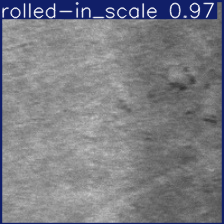

Detected: rolled-in_scale

--- Image: crazing_15.jpg ---
Actual defect: crazing

Analyzing: crazing_15.jpg

NO DEFECTS DETECTED
   (Confidence threshold: 50%)
Detected: NOTHING

--- Image: rolled-in_scale_220.jpg ---
Actual defect: rolled-in_scale

Analyzing: rolled-in_scale_220.jpg

DEFECTS DETECTED:
----------------------------------------
  rolled-in_scale      | Confidence: 96.51%


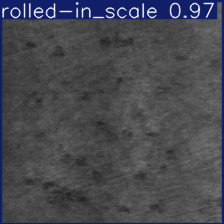

Detected: rolled-in_scale

--- Image: crazing_87.jpg ---
Actual defect: crazing

Analyzing: crazing_87.jpg

DEFECTS DETECTED:
----------------------------------------
  crazing              | Confidence: 91.30%


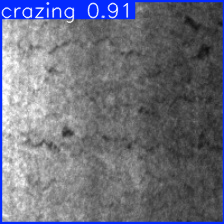

Detected: crazing

--- Image: crazing_285.jpg ---
Actual defect: crazing

Analyzing: crazing_285.jpg

DEFECTS DETECTED:
----------------------------------------
  crazing              | Confidence: 72.07%


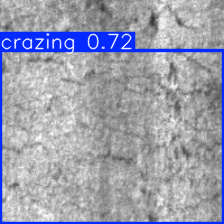

Detected: crazing

SAVING MODEL IN DIFFERENT FORMATS
Ultralytics 8.4.41 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/yolov11_training/steel_defects/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 10, 1029) (5.2 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.11.13 environment at: /usr
Resolved 12 packages in 157ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.46s
Installed 2 packages in 32ms
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.18.0 opset 19...
ONNX: slimming with onnxslim 0.1.91...
ONNX: expor

I0000 00:00:1776890127.631116      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13011 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
E0000 00:00:1776890130.834182      19 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1776890130.884149      19 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version spe

ERROR: The trace log is below.
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/utils/common_functions.py", line 314, in print_wrapper_func
    result = func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/utils/common_functions.py", line 388, in inverted_operation_enable_disable_wrapper_func
    result = func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/utils/common_functions.py", line 57, in get_replacement_parameter_wrapper_func
    func(*args, **kwargs)
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/ops/Mul.py", line 245, in make_node
    correction_process_for_accuracy_errors(
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/utils/common_functions.py", line 5987, in correction_process_for_accuracy_errors
    min_abs_err_perm_1: int = [idx for idx in range(len(validation_data_1.shape))]
                 

AttributeError: 'NoneType' object has no attribute 'shape'

In [3]:
# ============================================
# YOLOv11 - STEEL SURFACE DEFECT DETECTION
# ============================================
print("="*80)
print("YOLOv11 - STEEL SURFACE DEFECT DETECTION")
print("="*80)

# ============================================
# 1. Install YOLOv11
# ============================================
!pip install ultralytics -q

import os
import cv2
import yaml
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

# ============================================
# 2. Load Your Data
# ============================================
print("\n=== LOADING YOUR DATA ===")

with open('/kaggle/working/class_info.json', 'r') as f:
    class_info = json.load(f)

CLASS_NAMES = class_info['class_names']
IMAGES_DIR = class_info['images_dir']
NUM_CLASSES = len(CLASS_NAMES)

full_df = pd.read_csv('/kaggle/working/full_processed_dataset.csv')
print(f"Total images: {len(full_df)}")
print(f"Classes: {CLASS_NAMES}")

# ============================================
# 3. Prepare Image Paths
# ============================================
image_paths = []
labels = []

for idx, row in full_df.iterrows():
    img_path = row['file']
    if os.path.exists(img_path):
        image_paths.append(img_path)
        labels.append(row['label'])

print(f"Valid images found: {len(image_paths)}")

# ============================================
# 4. Split Data
# ============================================
print("\n=== SPLITTING DATA ===")

X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=0.1, 
    random_state=42, 
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.111,
    random_state=42, 
    stratify=y_temp
)

print(f"Training images: {len(X_train)}")
print(f"Validation images: {len(X_val)}")
print(f"Test images: {len(X_test)}")

# ============================================
# 5. Create YOLO Dataset Structure
# ============================================
print("\n=== CREATING YOLO DATASET STRUCTURE ===")

YOLO_DATASET = '/kaggle/working/yolo_dataset'

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(YOLO_DATASET, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET, split, 'labels'), exist_ok=True)

# ============================================
# 6. Convert Images to YOLO Format
# ============================================
def convert_to_yolo_format(image_paths, labels_list, split_name):
    for img_path, label in zip(image_paths, labels_list):
        img_name = os.path.basename(img_path)
        dest_img = os.path.join(YOLO_DATASET, split_name, 'images', img_name)
        shutil.copy2(img_path, dest_img)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        h, w = img.shape[:2]
        
        center_x = 0.5
        center_y = 0.5
        width = 0.95
        height = 0.95
        
        label_content = f"{label} {center_x} {center_y} {width} {height}"
        
        label_name = img_name.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(YOLO_DATASET, split_name, 'labels', label_name)
        
        with open(label_path, 'w') as f:
            f.write(label_content)
    
    print(f"  {split_name}: {len(image_paths)} images converted")

convert_to_yolo_format(X_train, y_train, 'train')
convert_to_yolo_format(X_val, y_val, 'val')
convert_to_yolo_format(X_test, y_test, 'test')

print("\nYOLO dataset created successfully!")

# ============================================
# 7. Create data.yaml File
# ============================================
print("\n=== CREATING data.yaml ===")

data_yaml = {
    'path': YOLO_DATASET,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': NUM_CLASSES,
    'names': CLASS_NAMES
}

yaml_path = os.path.join(YOLO_DATASET, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml saved at: {yaml_path}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {CLASS_NAMES}")

# ============================================
# 8. Train YOLOv11
# ============================================
print("\n" + "="*80)
print("STARTING YOLOv11 TRAINING")
print("="*80)

model = YOLO('yolo11n.pt')

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=224,
    batch=16,
    patience=20,
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0,
    device=0,
    workers=8,
    project='/kaggle/working/yolov11_training',
    name='steel_defects',
    exist_ok=True,
    verbose=True,
    seed=42
)

print("\nYOLOv11 training completed!")

# ============================================
# 9. Evaluate Model
# ============================================
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

best_model_path = '/kaggle/working/yolov11_training/steel_defects/weights/best.pt'
best_model = YOLO(best_model_path)

print("\n--- Validation Set Evaluation ---")
val_results = best_model.val(data=yaml_path, split='val', conf=0.5, iou=0.5)

print("\n--- Test Set Evaluation ---")
test_results = best_model.val(data=yaml_path, split='test', conf=0.5, iou=0.5)

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"Validation mAP@50: {val_results.box.map50:.4f} ({val_results.box.map50*100:.2f}%)")
print(f"Validation mAP@50-95: {val_results.box.map:.4f}")
print(f"Test mAP@50: {test_results.box.map50:.4f} ({test_results.box.map50*100:.2f}%)")
print(f"Test mAP@50-95: {test_results.box.map:.4f}")

# ============================================
# 10. Prediction Function for New Images
# ============================================
def detect_surface_defects(image_path, model_path=None, conf_threshold=0.5):
    if model_path is None:
        model_path = best_model_path
    
    model = YOLO(model_path)
    
    print(f"\n{'='*60}")
    print(f"Analyzing: {os.path.basename(image_path)}")
    print(f"{'='*60}")
    
    results = model(image_path, conf=conf_threshold, verbose=False)
    
    if len(results[0].boxes) == 0:
        print("\nNO DEFECTS DETECTED")
        print(f"   (Confidence threshold: {conf_threshold:.0%})")
        return None
    
    print(f"\nDEFECTS DETECTED:")
    print("-" * 40)
    
    detections = []
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = CLASS_NAMES[class_id]
        confidence = float(box.conf[0])
        bbox = box.xyxy[0].tolist()
        
        detections.append({
            'defect_type': class_name,
            'confidence': confidence,
            'bbox': bbox
        })
        
        print(f"  {class_name:20} | Confidence: {confidence:.2%}")
    
    results[0].show()
    
    return detections

# ============================================
# 11. Test Model on Random Images
# ============================================
print("\n" + "="*80)
print("SAMPLE PREDICTIONS ON VALIDATION SET")
print("="*80)

sample_indices = np.random.choice(len(X_val), min(5, len(X_val)), replace=False)

for idx in sample_indices:
    img_path = X_val[idx]
    true_label = CLASS_NAMES[y_val[idx]]
    
    print(f"\n--- Image: {os.path.basename(img_path)} ---")
    print(f"Actual defect: {true_label}")
    
    detections = detect_surface_defects(img_path, best_model_path, conf_threshold=0.5)
    
    if detections:
        detected_classes = [d['defect_type'] for d in detections]
        print(f"Detected: {', '.join(detected_classes)}")
    else:
        print("Detected: NOTHING")

# ============================================
# 12. Save Model in Different Formats
# ============================================
print("\n" + "="*80)
print("SAVING MODEL IN DIFFERENT FORMATS")
print("="*80)

onnx_path = best_model.export(format='onnx')
print(f"ONNX model saved: {onnx_path}")

tflite_path = best_model.export(format='tflite')
print(f"TFLite model saved: {tflite_path}")

results_df = pd.DataFrame(results.results)
results_df.to_csv('/kaggle/working/yolov11_training_results.csv', index=False)
print(f"Training results saved: yolov11_training_results.csv")

# ============================================
# 13. Plot Training Curves
# ============================================
print("\n=== PLOTTING TRAINING CURVES ===")

metrics_file = '/kaggle/working/yolov11_training/steel_defects/results.csv'
if os.path.exists(metrics_file):
    train_df = pd.read_csv(metrics_file)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    if 'metrics/mAP50(B)' in train_df.columns:
        axes[0].plot(train_df['epoch'], train_df['metrics/mAP50(B)'], 'b-', linewidth=2)
        axes[0].set_title('mAP@50', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('mAP@50')
        axes[0].grid(True, alpha=0.3)
    
    if 'train/box_loss' in train_df.columns:
        axes[1].plot(train_df['epoch'], train_df['train/box_loss'], 'r-', label='Box Loss', linewidth=2)
        axes[1].plot(train_df['epoch'], train_df['train/cls_loss'], 'g-', label='Class Loss', linewidth=2)
        axes[1].set_title('Training Losses', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    if 'metrics/precision(B)' in train_df.columns:
        axes[2].plot(train_df['epoch'], train_df['metrics/precision(B)'], 'orange', label='Precision', linewidth=2)
        axes[2].plot(train_df['epoch'], train_df['metrics/recall(B)'], 'purple', label='Recall', linewidth=2)
        axes[2].set_title('Precision & Recall', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Score')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/yolov11_training_curves.png', dpi=300)
    plt.show()
    print("Training curves saved")

# ============================================
# 14. Final Results
# ============================================
print("\n" + "="*80)
print("YOLOv11 MODEL READY FOR PRODUCTION")
print("="*80)
print(f"Model location: {best_model_path}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {CLASS_NAMES}")
print(f"\nValidation mAP@50: {val_results.box.map50*100:.2f}%")
print(f"Test mAP@50: {test_results.box.map50*100:.2f}%")
print("\nHow to use:")
print("  result = detect_surface_defects('your_image.jpg')")
print("\nOr with custom threshold:")
print("  result = detect_surface_defects('your_image.jpg', conf_threshold=0.7)")

# ============================================
# 15. Quick Test on Single Image
# ============================================
print("\n" + "="*80)
print("QUICK TEST - SINGLE IMAGE")
print("="*80)

test_img = X_val[0]
test_label = CLASS_NAMES[y_val[0]]
print(f"Test image: {os.path.basename(test_img)}")
print(f"Actual label: {test_label}")
print("\nRunning detection...")
detect_surface_defects(test_img, best_model_path, conf_threshold=0.5)

In [ ]:
from ultralytics import YOLO
import cv2


model = YOLO('/kaggle/working/yolov11_training/steel_defects/weights/best.pt')
CLASS_NAMES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

def detect_defect(image_path, confidence_threshold=0.4):
    """
    Detect surface defects in steel images
    """
    # Run detection
    results = model(image_path, conf=confidence_threshold)
    
    # Get results
    detections = []
    if len(results[0].boxes) > 0:
        for box in results[0].boxes:
            class_id = int(box.cls[0])
            detections.append({
                'defect': CLASS_NAMES[class_id],
                'confidence': float(box.conf[0]),
                'bbox': box.xyxy[0].tolist()
            })
    
    # Show image with boxes
    results[0].show()
    
    return detections

# ============================================================
# 
# ============================================================
img_path = '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images/pitted_surface/pitted_surface_101.jpg'
result = detect_defect(img_path, confidence_threshold=0.4)

print("\n" + "="*50)
if result:
    print(f"✅ Found {len(result)} defect(s):")
    for r in result:
        print(f"   - {r['defect']} (confidence: {r['confidence']:.2%})")
else:
    print("❌ No defects detected")

In [ ]:
# ============================================
# TEST YOLOv11 MODEL - AFTER TRAINING COMPLETES
# ============================================

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

print("="*60)
print("YOLOv11 - STEEL SURFACE DEFECT DETECTION")
print("="*60)

# ============================================
# 1. Load Trained Model
# ============================================
print("\nLoading model...")
model_path = '/kaggle/working/yolov11_training/steel_defects/weights/best.pt'

if os.path.exists(model_path):
    model = YOLO(model_path)
    print("Model loaded successfully!")
else:
    print("Model not found! Make sure training completed first.")
    print(f"   Looking for: {model_path}")
    exit()

# Class names (same as training)
CLASS_NAMES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
print(f"Classes: {CLASS_NAMES}")

# ============================================
# 2. Main Detection Function
# ============================================
def detect_defects(image_path, conf_threshold=0.4, show_result=True):
    """
    Detect defects in a steel surface image
    
    Parameters:
    - image_path: path to the image file
    - conf_threshold: confidence threshold (0.4 = 40%)
    - show_result: whether to display the result
    
    Returns:
    - detections: list of detected defects
    - result_image: path to saved result image
    """
    
    print(f"\n{'='*50}")
    print(f"Image: {os.path.basename(image_path)}")
    print(f"{'='*50}")
    
    # Check if image exists
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return None, None
    
    # Run detection
    results = model(image_path, conf=conf_threshold)
    
    # Extract detections
    detections = []
    if len(results[0].boxes) > 0:
        print(f"\nFound {len(results[0].boxes)} defect(s):")
        print("-" * 30)
        
        for i, box in enumerate(results[0].boxes, 1):
            class_id = int(box.cls[0])
            class_name = CLASS_NAMES[class_id]
            confidence = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            
            detections.append({
                'defect_type': class_name,
                'confidence': confidence,
                'bbox': [int(x1), int(y1), int(x2), int(y2)]
            })
            
            print(f"  {i}. {class_name.upper()}: {confidence:.2%}")
            print(f"     Location: x={int(x1)}-{int(x2)}, y={int(y1)}-{int(y2)}")
    else:
        print(f"\nNo defects detected (threshold: {conf_threshold:.0%})")
    
    # Save result
    result_path = f'/kaggle/working/result_{os.path.basename(image_path)}'
    results[0].save(result_path)
    print(f"\nResult saved: {result_path}")
    
    # Show result
    if show_result:
        results[0].show()
    
    return detections, result_path

# ============================================
# 3. Smart Detection with Rejection
# ============================================
def smart_detect(image_path, conf_threshold=0.5):
    """
    Detect defects with rejection for non-steel images
    """
    print(f"\n{'='*50}")
    print(f"Analyzing: {os.path.basename(image_path)}")
    print(f"{'='*50}")
    
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return None
    
    results = model(image_path, conf=conf_threshold)
    
    if len(results[0].boxes) > 0:
        max_conf = float(results[0].boxes[0].conf[0])
        
        # If confidence is high, it's likely a real defect
        if max_conf >= 0.6:
            class_name = CLASS_NAMES[int(results[0].boxes[0].cls[0])]
            print(f"\nDEFECT DETECTED: {class_name.upper()}")
            print(f"   Confidence: {max_conf:.2%}")
            results[0].show()
            return results
        else:
            print(f"\nLOW CONFIDENCE: {max_conf:.2%}")
            print("   Image may not be a steel surface or defect is subtle")
            return None
    else:
        print(f"\nNO DEFECTS DETECTED")
        print("   (Either no defects or not a steel surface image)")
        return None

# ============================================
# 4. Test Entire Folder
# ============================================
def test_folder(folder_path, conf_threshold=0.4):
    """
    Test all images in a folder
    """
    print(f"\n{'='*60}")
    print(f"TESTING FOLDER: {folder_path}")
    print(f"{'='*60}")
    
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return
    
    # Get all images
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
    images = []
    for ext in image_extensions:
        images.extend([f for f in os.listdir(folder_path) if f.lower().endswith(ext)])
    
    if not images:
        print(f"No images found in {folder_path}")
        return
    
    print(f"Found {len(images)} images\n")
    
    results_summary = []
    for img in images:
        img_path = os.path.join(folder_path, img)
        results = model(img_path, conf=conf_threshold)
        
        if len(results[0].boxes) > 0:
            for box in results[0].boxes:
                class_name = CLASS_NAMES[int(box.cls[0])]
                confidence = float(box.conf[0])
                results_summary.append({
                    'image': img,
                    'defect': class_name,
                    'confidence': confidence
                })
                print(f"  {img}: {class_name} ({confidence:.2%})")
        else:
            print(f"  {img}: No defects")
    
    # Summary
    print(f"\n{'='*50}")
    print(f"SUMMARY: {len(results_summary)} defects found in {len(images)} images")
    
    return results_summary

# ============================================
# 5. Test Examples
# ============================================

print("\n" + "="*60)
print("TESTING EXAMPLES")
print("="*60)

# Example 1: Test on a single image
print("\nExample 1: Test single image")
test_image = '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images/inclusion/inclusion_10.jpg'

if os.path.exists(test_image):
    detections, result_path = detect_defects(test_image, conf_threshold=0.4)
else:
    print(f"Test image not found. Please provide your own image path.")

# ============================================
# 6. Custom Test
# ============================================
print("\n" + "="*60)
print("CUSTOM TEST")
print("="*60)
print("\nYou can test your own images by uncommenting and modifying the code below:")
print("-" * 40)

# Change the path to your image
# custom_image = '/path/to/your/image.jpg'
# detections, result_path = detect_defects(custom_image, conf_threshold=0.4)

# ============================================
# 7. Test Entire Folder (Optional)
# ============================================
# If you have a folder with many images, use this code:
# test_folder('/kaggle/input/neu-surface-defect-database/NEU-DET/train/images', conf_threshold=0.4)

# ============================================
# 8. Quick Use Function
# ============================================
print("\n" + "="*60)
print("QUICK USE FUNCTION")
print("="*60)

def quick_test(image_path):
    """
    Simplest test function - use like this:
    quick_test('path/to/image.jpg')
    """
    results = model(image_path, conf=0.4)
    
    if len(results[0].boxes) > 0:
        for box in results[0].boxes:
            print(f"{CLASS_NAMES[int(box.cls[0])]}: {float(box.conf[0]):.2%}")
    else:
        print("No defects detected")
    
    results[0].show()
    return results

print("\nModel is ready!")
print("\nHow to use:")
print("  1. Test single image:")
print("     detect_defects('/path/to/image.jpg')")
print("\n  2. Quick test:")
print("     quick_test('/path/to/image.jpg')")
print("\n  3. Smart detection (rejects non-steel images):")
print("     smart_detect('/path/to/image.jpg')")
print("\n  4. Test entire folder:")
print("     test_folder('/path/to/folder')")

In [ ]:
from ultralytics import YOLO
import cv2


model = YOLO('/kaggle/working/yolov11_training/steel_defects/weights/best.pt')
CLASS_NAMES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

def detect_defect(image_path, confidence_threshold=0.4):
    """
    Detect surface defects in steel images
    """
    # Run detection
    results = model(image_path, conf=confidence_threshold)
    
    # Get results
    detections = []
    if len(results[0].boxes) > 0:
        for box in results[0].boxes:
            class_id = int(box.cls[0])
            detections.append({
                'defect': CLASS_NAMES[class_id],
                'confidence': float(box.conf[0]),
                'bbox': box.xyxy[0].tolist()
            })
    
    # Show image with boxes
    results[0].show()
    
    return detections

# ============================================================
# 
# ============================================================
img_path = '/kaggle/input/datasets/mohamedselem123/test-data/scratches_29.jpg'
result = detect_defect(img_path, confidence_threshold=0.4)

print("\n" + "="*50)
if result:
    print(f" Found {len(result)} defect(s):")
    for r in result:
        print(f"   - {r['defect']} (confidence: {r['confidence']:.2%})")
else:
    print(" No defects detected")